# 2.3. Training: ToxPredictor model

### 📘 Overview

This notebook trains multiple ML models on the DILImap training data, performs hyperparameter optimization, and selects a final ensemble model (random forests) to be stored as ToxPredictor for downstream prediction tasks. Note, that we trained our models on **scikit-learn 1.4.0** to ensure broad compatibility with downstream users and reproducibility across environments, while maintaining full compatibility with newer scikit-learn versions.

**Inputs**
- Training data (e.g., pathway-level signatures with binarized DILI labels)  
- Model configuration and search space definitions

**Output**  
- Trained base models with performance metrics  
- Optimal hyperparameters per model type  
- **Final ensemble model** (random forests), saved to S3
- **Suppl. Figures S2-S5** with model training details

In [1]:
%%capture

!pip install scikit-learn==1.4.0
!pip install xgboost
!pip install lightgbm
!pip install matplotlib_venn

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from concurrent.futures import ThreadPoolExecutor, as_completed

import dilimap as dmap
from dilimap.utils import groupby, crosstab
from dilimap.models import ToxPredictor

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
dmap.logging.print_version()

Running dilimap 1.0.4.dev0+gcb566f869.d20251007 (python 3.11.8) on 2025-10-07 18:01.


## 1a. Pull training data and map DILI labels

In [5]:
adata = dmap.s3.read('training_data_pathways.h5ad')

Package: s3://dilimap/public/data. Top hash: 155a2b3b63


In [6]:
dmap.utils.map_dili_labels_and_cmax(adata)

Package: s3://dilimap/public/data. Top hash: 155a2b3b63
Package: s3://dilimap/public/data. Top hash: 155a2b3b63
Package: s3://dilimap/public/data. Top hash: 155a2b3b63


In [7]:
df_groupby = groupby(adata, 'compound_name')

cols = [
    'Most-DILI-Concern',
    'Less-DILI-Concern',
    'Ambiguous DILI-concern',
    'No-DILI-Concern',
]
crosstab(df_groupby, ['livertox_score', 'DILIrank'], np.sum).replace(np.nan, '')[cols]

DILIrank,Most-DILI-Concern,Less-DILI-Concern,Ambiguous DILI-concern,No-DILI-Concern
livertox_score,,,,
A,27,9,0,0
A [HD],1,2,0,0
B,13,28,0,1
C,11,34,0,1
D,3,27,0,3
E,0,10,1,31
E*,0,7,0,7


In [8]:
print(f'Total no. of training compounds: {len(df_groupby)}')
df_groupby['DILI_label'].value_counts(sort=False)

Total no. of training compounds: 249


DILI_label
DILI (likely)         73
DILI (few cases)      69
DILI (known)          25
DILI (withdrawn)      13
No DILI               52
No DILI (unlikely)    17
Name: count, dtype: int64

## 1b. Define dose-specific DILI training labels

In [9]:
## Dose/cmpd-specific DILI annotations

dose_uM, cmax_uM = adata.obs['dose_uM'], adata.obs['Cmax_uM']
is_neg = adata.obs['DILI_label'].isin(['No DILI']) & (
    (dose_uM < 80 * cmax_uM) | (adata.obs['dose_level'] == 'Low')
)
is_pos = adata.obs['DILI_label'].isin(
    ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)']
) & ((dose_uM > 20 * cmax_uM) | (adata.obs['dose_level'] == 'High'))

adata.obs['DILI'] = np.where(is_neg, False, np.where(is_pos, True, np.nan))

In [10]:
# Visualizing labeling strategy

df_crosstab = crosstab(adata, ['compound_name', 'dose_level', 'DILI'])
df_crosstab['DILI_label'] = df_crosstab.index.map(
    adata.obs.groupby('compound_name')['DILI_label'].first()
)
df_crosstab[:10].style.background_gradient(cmap='RdBu_r', vmin=-2, vmax=2.5).format(
    precision=2
).highlight_null('white')

dose_level,Low,Middle,Mid-High,High,DILI_label
compound_name,,,,,
Abacavir,nan,nan,1.00,1.00,DILI (likely)
Acarbose,1.00,1.00,1.00,1.00,DILI (likely)
Acetaminophen,nan,nan,nan,1.00,DILI (known)
Alaproclate,nan,nan,nan,1.00,DILI (withdrawn)
Albendazole,nan,nan,1.00,1.00,DILI (likely)
Allopurinol,nan,nan,nan,1.00,DILI (known)
Alvimopan,0.00,nan,nan,nan,No DILI
Ambrisentan,0.00,0.00,nan,nan,No DILI
Amiodarone,nan,nan,nan,1.00,DILI (known)


In [11]:
adata.obs['DILI'].value_counts()

DILI
1.0    232
0.0     91
Name: count, dtype: int64

## 1c. Compound filtering

In [12]:
df_cmpd_DEGs = adata.obs.groupby('compound_name', observed=True)['n_DEG'].max()
# exclude inactive cmpds that have at max 40 DEGs
adata.obs['valid_cmpd'] = ~adata.obs_names.isin(df_cmpd_DEGs.index[df_cmpd_DEGs < 10])

# exclude cmpds with insufficient dose range (top dose < Cmax)
df_cmpd_dose = adata.obs.groupby('compound_name', observed=True)[
    ['dose_uM', 'Cmax_uM']
].max()
adata.obs['valid_cmpd'] &= ~adata.obs_names.isin(
    df_cmpd_dose.index[df_cmpd_dose['dose_uM'] < df_cmpd_dose['Cmax_uM']]
)

# include cmpds with strong signal even if dose range is insufficient
adata.obs['valid_cmpd'] |= adata.obs_names.isin(df_cmpd_DEGs.index[df_cmpd_DEGs > 2000])
adata.obs['valid_cmpd'] |= ~adata.obs['LDH_IC10_uM'].isna()

print(
    'Compounds left post-filtering:',
    len(set(adata.obs['compound_name'][adata.obs['valid_cmpd']])),
    '/',
    len(set(adata.obs['compound_name'])),
)

Compounds left post-filtering: 246 / 249


## 1d. Feature filtering & data clipping

In [13]:
# Remove isignificant pathways or pseudogenes

if True:  ## pathway signature
    adata.var['FDR_min'] = np.nanmin(adata.layers['FDR'], 0)
    print(
        f'Retaining {(adata.var["FDR_min"] < 1e-3).sum()}/{adata.n_vars} significant pathways'
    )
    adata = adata[:, adata.var['FDR_min'] < 1e-3]

else:  ## gene signatures
    adata.var['pseudogene'] = adata.var_names.str.contains(r'\.')
    print(f'Filtering out {adata.var["pseudogene"].sum()} pseudogenes')
    adata = adata[:, ~adata.var['pseudogene']].copy()

Retaining 186/472 significant pathways


In [14]:
if False:  # consider clipping data when observing outliers in gene signature
    adata.X = np.nan_to_num(adata.X)  # set nans to zero

    lb, ub = np.percentile(adata.X, [2, 98], axis=0)
    adata.X = np.clip(adata.X, lb, ub)  # clip to [2,98] percentiles

    adata.X = adata.X * (adata.X > 1)  # clip to DES > 1 (pval < 0.1)
    adata.X = np.clip(adata.X, 1, 10)  # clip to DES < 10 (pval > 1e-10)

## 2a. Model selection and hyperparameter optimization

In [15]:
random_state = seed = 42

In [16]:
classifiers = {
    # Logistic Regression with L2 regularization
    'LogisticRegression': [
        dict(solver='lbfgs', penalty='l2', max_iter=1000, random_state=random_state),
        dict(C=[0.0001, 0.001, 0.01, 0.1, 1, 10, 100], class_weight=['balanced', None]),
    ],
    # Support Vector Classifier with RBF kernel
    'SVC': [
        dict(kernel='rbf', gamma='scale', probability=True, random_state=random_state),
        dict(C=[0.1, 1, 10]),
    ],
    # Random Forest with max_depth and regularization parameters
    'RandomForestClassifier': [
        dict(n_estimators=100, random_state=random_state),
        dict(
            max_depth=[1, 2, 3, 4, 5, None],
            min_samples_split=[2, 3],
            min_samples_leaf=[1, 2],
            class_weight=['balanced', None],
        ),
    ],
    # Gradient Boosting Trees with learning rate and depth tuning
    'GradientBoostingClassifier': [
        dict(n_estimators=100, random_state=random_state),
        dict(
            learning_rate=[0.01, 0.1],
            max_depth=[1, 2, 3, 4, 5],
            min_samples_split=[2, 3],
            min_samples_leaf=[1, 2],
        ),
    ],
    # Histogram-based Gradient Boosting (faster, scalable)
    'HistGradientBoostingClassifier': [
        dict(random_state=random_state),
        dict(
            learning_rate=[0.01, 0.1],
            max_depth=[1, 2, 3, 4, 5],
            l2_regularization=[0.0, 0.1, 1.0],
        ),
    ],
    # Multi-layer Perceptron with deeper architectures and tuning
    'MLPClassifier': [
        dict(max_iter=1000, early_stopping=True, random_state=random_state),
        dict(
            learning_rate_init=[0.001, 0.0005],
            alpha=[1e-4, 1e-3, 1e-2, 1e-1],
            hidden_layer_sizes=[(30,), (50,), (100,), (100, 50), (100, 100)],
        ),
    ],
    # XGBoost (gradient boosting, often among top performers)
    'XGBClassifier': [
        dict(eval_metric='logloss', random_state=random_state),
        dict(learning_rate=[0.01, 0.1], max_depth=[1, 2, 3, 4, 5]),
    ],
    # LightGBM (fast gradient boosting with histogram-based learning)
    'LGBMClassifier': [
        dict(verbosity=-1, random_state=random_state),
        dict(learning_rate=[0.01, 0.1], max_depth=[1, 2, 3, 4, 5]),
    ],
}

In [17]:
# Data Preparation
adata_clean = adata.copy()
adata_clean.var_names = adata_clean.var_names.str.replace(r'[^\w\-]', '_', regex=True)

# Split labeled and unlabeled data
mask_labeled = (~adata_clean.obs['DILI'].isna()) & adata.obs['valid_cmpd']
adata_labeled = adata_clean[mask_labeled].copy()
adata_unlabeled = adata_clean[~mask_labeled].copy()

# Set meaningful obs_names for grouping
adata_labeled.obs_names = (
    adata_labeled.obs['compound_name'].astype(str)
    + '_'
    + adata_labeled.obs['dose_level'].astype(str)
).values

# Prepare inputs for model training
X_train = adata_labeled.to_df()
y_train = adata_labeled.obs['DILI']
group_labels = adata_labeled.obs['compound_name']
compound_dose_index = adata_labeled.obs_names

# For inter-fold correlation test: only high-dose samples
X_high_dose = adata_clean[
    (~adata_clean.obs['DILI'].isna()) & (adata_clean.obs['dose_level'] == 'High')
].to_df()

/opt/miniconda3/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/miniconda3/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [18]:
# Model Evaluation Function

import random
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    average_precision_score,
)


def evaluate_model(
    tune_id,
    model_name,
    model_params,
    X_train,
    y_train,
    group_labels,
    compound_dose_index,
    X_high_dose,
    adata_unlabeled,
    n_splits=5,
):
    np.random.seed(seed)
    random.seed(seed)

    try:
        model_params = model_params.copy()
        model = ToxPredictor(model=model_name, model_params=model_params)

        # Train with cross-validation
        model.cross_validate(X_train, y_train, n_splits=n_splits, groups=group_labels)

        # Predict with CV and ensemble
        df_preds = pd.DataFrame({'DILI': y_train})
        df_preds['cv_pred'] = model.predict_proba_cv()[1].astype(float)
        df_preds['ens_pred'] = model.predict_proba(X_train)[1].astype(float)

        # Aggregate by compound-dose
        df_grouped = df_preds.groupby(compound_dose_index).mean()
        y_true = df_grouped['DILI']
        y_score = df_grouped['cv_pred']
        y_pred_bin = (y_score > 0.5).astype(int)

        # Inter-fold robustness
        y_preds_folds = np.stack(
            [m.predict_proba(X_high_dose)[:, -1] for m in model.estimators]
        )
        is_extreme = (
            y_preds_folds < np.percentile(y_preds_folds, 10, axis=1)[:, None]
        ) | (y_preds_folds > np.percentile(y_preds_folds, 90, axis=1)[:, None])
        interfold_robustness = np.corrcoef(
            y_preds_folds[:, np.any(is_extreme, axis=0)]
        ).min()

        # Dose monotonicity
        adata_unlabeled.obs['cv_pred'] = model.predict_proba(
            adata_unlabeled.to_df()
        ).iloc[:, -1]
        df_dose = crosstab(adata_unlabeled, ['compound_name', 'dose_level', 'cv_pred'])[
            ['Mid-High', 'High']
        ].dropna()
        dose_monotonicity = np.mean(df_dose['High'] > df_dose['Mid-High'])

        # Standard metrics
        metrics = {
            'AUC (validation)': roc_auc_score(y_true, y_score),
            'AUC (training)': roc_auc_score(y_true, df_grouped['ens_pred']),
            'Precision': precision_score(y_true, y_pred_bin),
            'Recall': recall_score(y_true, y_pred_bin),
            'F1 score': f1_score(y_true, y_pred_bin),
            'Accuracy': accuracy_score(y_true, y_pred_bin),
            'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred_bin),
            'Average Precision': average_precision_score(y_true, y_score),
            'Inter-fold correlation': interfold_robustness,
            'Monotonic dose response': dose_monotonicity,
            'Classifier': model_name,
        }

        return tune_id, df_grouped, metrics

    except Exception as e:
        print(f'[{tune_id}] Evaluation failed: {e}')
        return tune_id, None, None

In [19]:
# Hyperparameter Sweep
from itertools import product
from copy import deepcopy

np.random.seed(seed)
random.seed(seed)

# Generate hyperparameter tuning tasks
tasks = []
for model_name, (base_params, tunables) in classifiers.items():
    for combo in product(*tunables.values()):
        params = deepcopy(base_params)
        for k, v in zip(tunables.keys(), combo):
            params[k] = v
        tune_id = f'{model_name}__' + '__'.join(
            f'{k}={str(v).replace(" ", "")}' for k, v in zip(tunables.keys(), combo)
        )
        tasks.append((tune_id, model_name, params))

# Run evaluations in parallel
results = []
predictions = {}

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {
        executor.submit(
            evaluate_model,
            tune_id,
            model_name,
            model_params,
            X_train,
            y_train,
            group_labels,
            compound_dose_index,
            X_high_dose,
            adata_unlabeled,
        ): tune_id
        for (tune_id, model_name, model_params) in tasks
    }

    for future in as_completed(futures):
        tune_id = futures[future]
        try:
            tune_id, df_preds, metrics = future.result()
            if metrics:
                metrics['tune_id'] = tune_id
                predictions[tune_id] = df_preds
                results.append(metrics)
        except Exception as e:
            print(f'[{tune_id}] Future failed: {e}')

# Results summary
df_scores = pd.DataFrame(results).set_index('tune_id').reset_index()

In [20]:
pd.DataFrame(results).set_index('tune_id').reset_index().to_csv('model_selection_results.csv')

In [21]:
print(len(df_scores))

195


In [22]:
# Filter failed runs
df_scores = df_scores[(df_scores['Precision'] > 0.1) & (df_scores['Recall'] > 0.1)]

# Filter models with strong performance and cross-validation stability
selected_models = df_scores[
    (df_scores['AUC (validation)'] > 0.7)
    & (df_scores['Precision'] > 0.8)
    & (df_scores['Recall'] > 0.6)
    & (df_scores['Monotonic dose response'] > 0.6)
    & (df_scores['Inter-fold correlation'] > 0.8)
]

# Select top 5 models per classifier based on validation AUC
top_models = (
    selected_models.sort_values('AUC (validation)', ascending=False)
    .groupby('Classifier')
    .head(5)
)

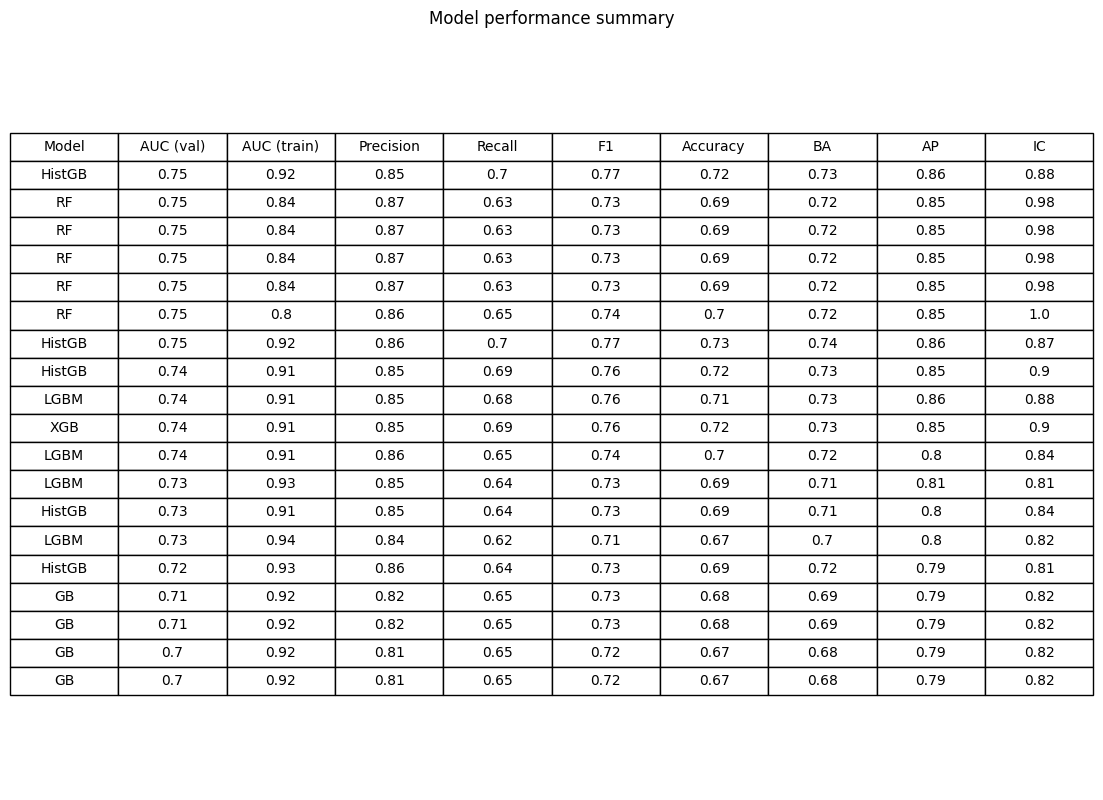

In [23]:
import pandas as pd

# Select and rename columns for compact display
df_display = top_models[
    [
        'tune_id',
        'AUC (validation)',
        'AUC (training)',
        'Precision',
        'Recall',
        'F1 score',
        'Accuracy',
        'Balanced Accuracy',
        'Average Precision',
        'Inter-fold correlation',
        'Monotonic dose response',
    ]
].copy()

# Abbreviate column names
df_display.columns = [
    'tune_id',
    'AUC (val)',
    'AUC (train)',
    'Precision',
    'Recall',
    'F1',
    'Accuracy',
    'BA',
    'AP',
    'IC',
    'MD',
]

# Abbreviate model names
model_map = {
    'RandomForestClassifier': 'RF',
    'HistGradientBoostingClassifier': 'HistGB',
    'XGBClassifier': 'XGB',
    'LGBMClassifier': 'LGBM',
    'GradientBoostingClassifier': 'GB',
    'LogisticRegression': 'LogReg',
    'SVC': 'SVC',
    'MLPClassifier': 'MLP',
}
df_display['Model'] = (
    df_display['tune_id'].str.extract(r'([^\_]+Classifier)').iloc[:, 0].map(model_map)
)
df_display['Details'] = df_display['tune_id'].str.replace(
    r'^.*?Classifier__', '', regex=True
)

# Reorder columns for presentation
df_display = df_display[
    [
        'Model',
        'AUC (val)',
        'AUC (train)',
        'Precision',
        'Recall',
        'F1',
        'Accuracy',
        'BA',
        'AP',
        'IC',
    ]
]  #'Details',

# Plot table
fig, ax = plt.subplots(figsize=(11, 0.5 + 0.4 * len(df_display)))
ax.axis('off')

table = ax.table(
    cellText=df_display.round(2).values,
    colLabels=df_display.columns,
    cellLoc='center',
    loc='center',
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.4)  # slightly wider column spacing

plt.title('Model performance summary', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

In [24]:
id_selected_model = top_models.query(
    "tune_id == 'RandomForestClassifier__max_depth=2__min_samples_split=2__min_samples_leaf=1__class_weight=None'"
).index[0]

print(id_selected_model, top_models.loc[id_selected_model]['tune_id'].split('__'))

26 ['RandomForestClassifier', 'max_depth=2', 'min_samples_split=2', 'min_samples_leaf=1', 'class_weight=None']


In [25]:
def plot_metrics(df, x, y, hue='Classifier', highlight_id=None):
    # Example: AUC vs. Dose Response
    plt.figure(figsize=(4, 3))
    sns.scatterplot(data=df, x=x, y=y, hue=hue, s=50)

    if highlight_id in df.index:
        row = df.loc[highlight_id]
        plt.scatter(
            row[x], row[y], marker='*', s=100, color='green', label='Selected method'
        )

    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(True)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

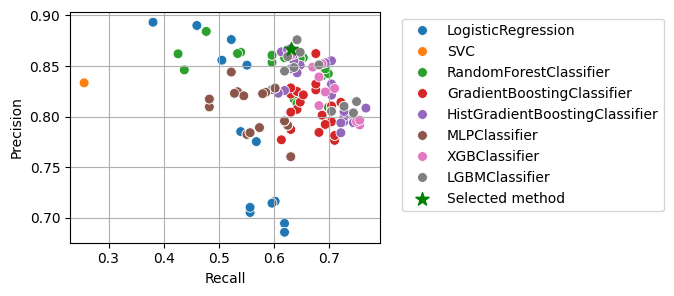

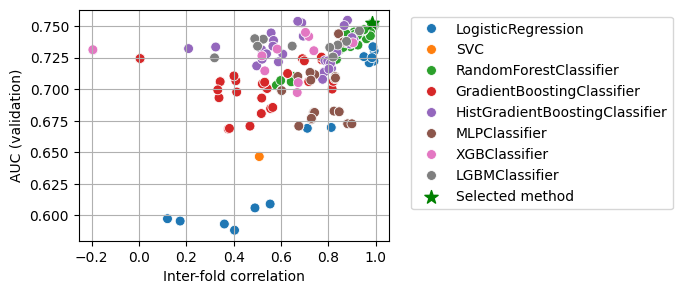

In [26]:
highlight_id = id_selected_model

plot_metrics(df_scores, 'Recall', 'Precision', highlight_id=highlight_id)
plot_metrics(
    df_scores, 'Inter-fold correlation', 'AUC (validation)', highlight_id=highlight_id
)

## 2b. Selection of number of folds for ensembling

In [27]:
np.random.seed(seed)
random.seed(seed)

n_splits_list = [5, 10, 20, 30, 40, 50]
results = []
predictions = []

# Only evaluate RandomForest
model_name = 'RandomForestClassifier'
model_params = dict(
    random_state=random_state,
    n_estimators=100,
    max_depth=2,
    min_samples_split=2,
    min_samples_leaf=1,
)

# Create evaluation tasks
tasks = [
    (f'{model_name}__n_splits={n}', model_name, model_params, n) for n in n_splits_list
]

# Run evaluations in parallel
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {
        executor.submit(
            evaluate_model,
            tune_id,
            model_name,
            model_params,
            X_train,
            y_train,
            group_labels,
            compound_dose_index,
            X_high_dose,
            adata_unlabeled,
            n_splits,
        ): tune_id
        for (tune_id, model_name, model_params, n_splits) in tasks
    }

    for future in as_completed(futures):
        tune_id = futures[future]
        try:
            tune_id, df_preds, metrics = future.result()
            if metrics:
                metrics['tune_id'] = tune_id
                predictions.append((tune_id, df_preds))
                results.append(metrics)
        except Exception as e:
            print(f'[{tune_id}] Future failed: {e}')

# Convert results to DataFrame
df_scores_splits = pd.DataFrame(results).set_index('tune_id').reset_index()

In [28]:
std_dict = {}
for n_splits in n_splits_list:
    model = ToxPredictor(model=model_name, model_params=model_params)
    model.cross_validate(X_train, y_train, n_splits=n_splits, groups=group_labels)
    std_dict[str(n_splits)] = (
        model.predict_proba_across_estimators(adata_unlabeled).std(1).values
    )

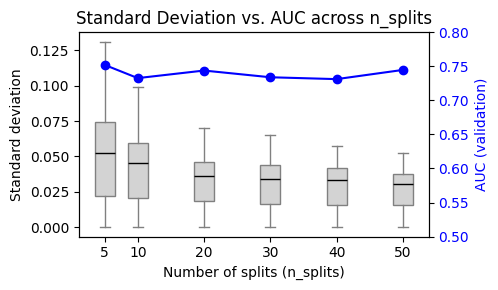

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Setup
df_melted = pd.DataFrame(std_dict).melt(var_name='x', value_name='y')
df_melted['x'] = df_melted['x'].astype(int)
x_vals = sorted(df_melted['x'].unique())
data_per_x = [df_melted[df_melted['x'] == x]['y'].values for x in x_vals]
df_scores_splits['n_splits'] = n_splits_list

# Create plot
fig, ax1 = plt.subplots(figsize=(5, 3))

# Matplotlib boxplot with correct numeric alignment
ax1.boxplot(
    data_per_x,
    positions=x_vals,
    widths=3,
    patch_artist=True,
    boxprops=dict(facecolor='lightgray', color='gray'),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray'),
    flierprops=dict(marker='o', markersize=2, linestyle='none', markerfacecolor='gray'),
)

ax1.set_ylabel('Standard deviation', color='black')
ax1.set_xlabel('Number of splits (n_splits)')
ax1.tick_params(axis='y', labelcolor='black')

# AUC line on secondary axis
ax2 = ax1.twinx()
ax2.plot(
    df_scores_splits['n_splits'],
    df_scores_splits['AUC (validation)'],
    marker='o',
    color='blue',
    label='AUC (validation)',
)
ax2.set_ylabel('AUC (validation)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0.5, 0.8)

ax1.set_title('Standard Deviation vs. AUC across n_splits')
fig.tight_layout()
plt.show()

**Conclusion**: We chose the 30-fold ensemble model for its optimal balance of performance and stability. While overall performance is similar across folds, 30-folds offer greater consistency and smoother predictions, making it best suited for ensembling the fold models.

## 2c. Selection of optimal MOS threshold

In [30]:
from dilimap.models import ToxPredictor

In [31]:
idx = (~adata.obs['DILI'].isna()) & adata.obs['valid_cmpd']
data = adata[idx].copy()

cmpd_dose = (
    data.obs['compound_name'].astype(str) + '_' + data.obs['dose_level'].astype(str)
)
X = data.to_df().set_index(cmpd_dose)
y, groups = data.obs['DILI'], data.obs['compound_name']

/opt/miniconda3/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [32]:
model_params = dict(
    random_state=random_state,
    n_estimators=100,
    max_depth=2,
    min_samples_split=2,
    min_samples_leaf=1,
)

model = ToxPredictor(model='rf', model_params=model_params)

In [33]:
model.cross_validate(X, y, n_splits=30, groups=data.obs['compound_name'])

In [34]:
data.obs['DILI_prob_cv'] = model.predict_cv().values
data.obs['DILI_prob_ens'] = model.predict(X).values

In [35]:
df_res_probs = (
    data.obs[['DILI', 'DILI_prob_cv', 'DILI_prob_ens']]
    .astype(float)
    .groupby(cmpd_dose)
    .mean()
)

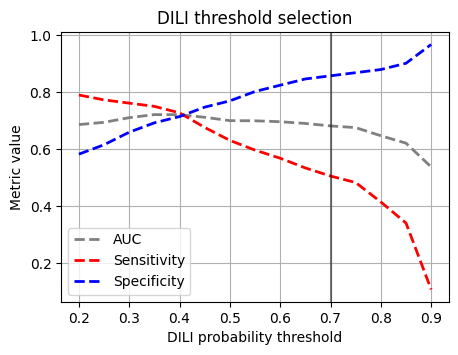

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.2, 0.9, 15)
sens, spec, aucs = [], [], []

for t in thresholds:
    pred = (df_res_probs['DILI_prob_cv'] > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(df_res_probs['DILI'], pred).ravel()

    sens.append(tp / (tp + fn) if (tp + fn) else np.nan)
    spec.append(tn / (tn + fp) if (tn + fp) else np.nan)
    aucs.append(roc_auc_score(df_res_probs['DILI'], pred))

plt.figure(figsize=(5, 3.5))
plt.plot(thresholds, aucs, '--', label='AUC', color='grey', lw=2)
plt.plot(thresholds, sens, '--', label='Sensitivity', color='red', lw=2)
plt.plot(thresholds, spec, '--', label='Specificity', color='blue', lw=2)
plt.axvline(0.7, color='k', alpha=0.5)
plt.xlabel('DILI probability threshold')
plt.ylabel('Metric value')
plt.title('DILI threshold selection')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
df_res_margins = model.compute_safety_margin(data, y_thresh=0.7)
df_res_margins['DILI_label'] = df_res_margins.index.map(
    groupby(adata, 'compound_name')['DILI_label']
)

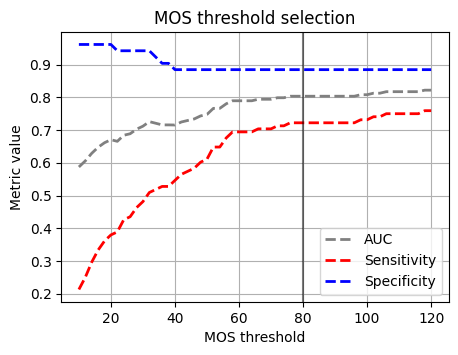

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score

# Binary DILI label: 1 = toxic, 0 = non-toxic
dili_labels = ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)', 'No DILI']
df = df_res_margins[df_res_margins['DILI_label'].isin(dili_labels)].copy()
df['DILI'] = df['DILI_label'].str.startswith('DILI').astype(int)

thresholds = np.linspace(10, 120, 56)
sens, spec, aucs = [], [], []

for t in thresholds:
    pred = (df['MOS_ToxPredictor'] < t).astype(int)
    tn, fp, fn, tp = confusion_matrix(df['DILI'], pred).ravel()

    sens.append(tp / (tp + fn) if (tp + fn) else np.nan)
    spec.append(tn / (tn + fp) if (tn + fp) else np.nan)
    try:
        aucs.append(roc_auc_score(df['DILI'], pred))
    except ValueError:
        aucs.append(np.nan)  # In case only one class is predicted

# Plot
plt.figure(figsize=(5, 3.5))
plt.plot(thresholds, aucs, '--', label='AUC', color='grey', lw=2)
plt.plot(thresholds, sens, '--', label='Sensitivity', color='red', lw=2)
plt.plot(thresholds, spec, '--', label='Specificity', color='blue', lw=2)
plt.axvline(80, color='k', alpha=0.5)
plt.xlabel('MOS threshold')
plt.ylabel('Metric value')
plt.title('MOS threshold selection')
plt.legend()
plt.grid(True)
plt.show()

## 2d. Selection of total Cmax over free Cmax

In [39]:
adata_sub = adata[~adata.obs['free_Cmax_uM'].isna()].copy()

mult = adata_sub.obs['Cmax_uM'].mean() / adata_sub.obs['free_Cmax_uM'].mean()
vmax = 300

df_res_margins = model.compute_safety_margin(adata_sub, vmax=vmax)
df_res_margins['DILI_label'] = df_res_margins.index.map(
    groupby(adata_sub, 'compound_name')['DILI_label']
)
df_res_margins['n_DEG_mean'] = df_res_margins.index.map(
    groupby(adata_sub, 'compound_name')['n_DEG_mean']
)

df_res_margins['DILI'] = ~df_res_margins['DILI_label'].str.startswith('No DILI')
df_res_margins['MOS_total_Cmax'] = df_res_margins['MOS_ToxPredictor']

df_res_free = model.compute_safety_margin(adata_sub, cmax_col='free_Cmax_uM', vmax=vmax * mult)
df_res_margins['MOS_free_Cmax'] = df_res_free['MOS_ToxPredictor']

/opt/miniconda3/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


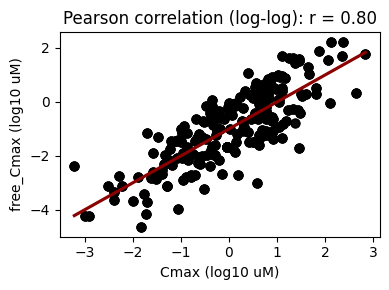

In [40]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np

# Drop NaNs and non-positive values (log scale can't handle zero or negative)
df_filtered = adata.obs.dropna(subset=['Cmax_uM', 'free_Cmax_uM']).copy()
df_filtered = df_filtered[df_filtered['free_Cmax_uM'] > 0]

# Compute Pearson correlation on log-transformed values
log_x = np.log10(df_filtered['Cmax_uM'])
log_y = np.log10(df_filtered['free_Cmax_uM'])
r, p_value = pearsonr(log_x, log_y)

# Plot
plt.figure(figsize=(4, 3))
sns.regplot(
    x=log_x, y=log_y, ci=None, color='darkred', scatter_kws={'s': 40, 'color': 'k'}
)

plt.xlabel('Cmax (log10 uM)')
plt.ylabel('free_Cmax (log10 uM)')
plt.title(f'Pearson correlation (log-log): r = {r:.2f}')
plt.tight_layout()
plt.show()

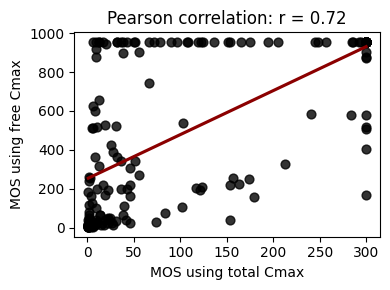

In [41]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Drop NaNs and non-positive values (log scale can't handle zero or negative)
df_filtered = df_res_margins.dropna(subset=['MOS_total_Cmax', 'MOS_free_Cmax']).copy()

# Compute Pearson correlation on log-transformed values
r, p_value = pearsonr(df_filtered['MOS_total_Cmax'], df_filtered['MOS_free_Cmax'])

# Plot
plt.figure(figsize=(4, 3))
sns.regplot(
    x=df_filtered['MOS_total_Cmax'],
    y=df_filtered['MOS_free_Cmax'],
    ci=None,
    color='darkred',
    scatter_kws={'s': 40, 'color': 'k'},
)

plt.xlabel('MOS using total Cmax')
plt.ylabel('MOS using free Cmax')
plt.title(f'Pearson correlation: r = {r:.2f}')
plt.tight_layout()
plt.show()

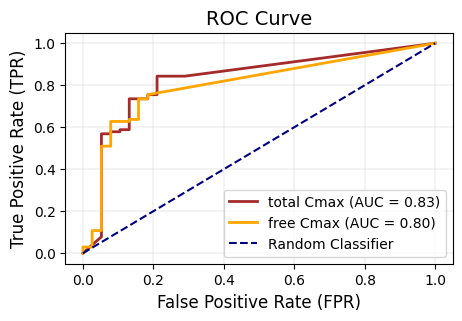

In [42]:
df = df_res_margins[
    df_res_margins['DILI_label'].isin(
        ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)', 'No DILI']
    )
]
y_true = ~df['DILI_label'].isin(['No DILI'])

plt.figure(figsize=(5, 3))
dmap.pl.roc_curve(
    y_true, df['MOS_total_Cmax'], label='total Cmax', inverse=True, show=False
)
dmap.pl.roc_curve(
    y_true,
    df['MOS_free_Cmax'],
    label='free Cmax',
    color='orange',
    inverse=True,
    show=True,
)

In [43]:
adata_dilimap = dmap.datasets.DILImap_data()

Package: s3://dilimap/public/data. Top hash: 155a2b3b63
Package: s3://dilimap/public/data. Top hash: 155a2b3b63


/opt/miniconda3/envs/py311/lib/python3.11/site-packages/anndata/_core/merge.py:1309: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


In [44]:
dmap.utils.map_dili_labels_and_cmax(adata_dilimap)

Package: s3://dilimap/public/data. Top hash: 155a2b3b63
Package: s3://dilimap/public/data. Top hash: 155a2b3b63
Package: s3://dilimap/public/data. Top hash: 155a2b3b63


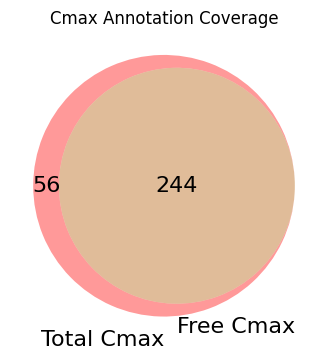

In [45]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

df = adata_dilimap.obs

# Assume these are sets of compound IDs
compounds_with_total = set(
    df.groupby(['compound_name', 'SPLIT'], observed=True)['Cmax_uM']
    .mean()
    .dropna()
    .index
)
compounds_with_free = set(
    df.groupby(['compound_name', 'SPLIT'], observed=True)['free_Cmax_uM']
    .mean()
    .dropna()
    .index
)

plt.figure(figsize=(4, 4))
venn = venn2(
    [compounds_with_total, compounds_with_free], set_labels=('Total Cmax', 'Free Cmax')
)

if venn.get_label_by_id('01'):
    if venn.get_label_by_id('01').get_text() == '0':
        venn.get_label_by_id('01').set_text('')

# Set font size for all region labels
for label in venn.set_labels:
    label.set_fontsize(16)  # set size for set labels (e.g., "Total Cmax")

for label in venn.subset_labels:
    if label:  # skip None (e.g., if a region is empty)
        label.set_fontsize(16)  # set size for numbers inside the circles

plt.title('Cmax Annotation Coverage')
plt.show()

## 3a. Final model training and cross-validation

In [46]:
random_state = seed = 42

In [47]:
from dilimap.models import ToxPredictor

In [48]:
idx = (~adata.obs['DILI'].isna()) & adata.obs['valid_cmpd']
data = adata[idx].copy()

cmpd_dose = (
    data.obs['compound_name'].astype(str) + '_' + data.obs['dose_level'].astype(str)
)
X = data.to_df().set_index(cmpd_dose)
y, groups = data.obs['DILI'], data.obs['compound_name']

/opt/miniconda3/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [49]:
model_params = dict(
    random_state=random_state,
    n_estimators=100,
    max_depth=2,
    min_samples_split=2,
    min_samples_leaf=1,
)

model = ToxPredictor(model='rf', model_params=model_params)

In [50]:
model.cross_validate(X, y, n_splits=30, groups=data.obs['compound_name'])

In [51]:
data.obs['DILI_prob_cv'] = model.predict_cv().values
data.obs['DILI_prob_ens'] = model.predict(X).values

## 3b. Cross-validation of DILI probabilities

In [52]:
df_res = (
    data.obs[['DILI', 'DILI_prob_cv', 'DILI_prob_ens']]
    .astype(float)
    .groupby(cmpd_dose)
    .mean()
)

In [53]:
from sklearn.metrics import confusion_matrix, roc_auc_score

tn, fp, fn, tp = confusion_matrix(df_res['DILI'], df_res['DILI_prob_cv'] > 0.7).ravel()
auc_score = roc_auc_score(df_res['DILI'], df_res['DILI_prob_cv'])

print(
    f'AUC: {np.round(auc_score, 2)} '
    f'\nSensitivity: {tp}/{(tp + fn)} ({int(tp / (tp + fn) * 100)}%) '
    f'\nSpecificity: {tn}/{(tn + fp)} ({int(tn / (tn + fp) * 100)}%)'
)

AUC: 0.73 
Sensitivity: 89/176 (50%) 
Specificity: 78/91 (85%)


In [54]:
tn, fp, fn, tp = confusion_matrix(df_res['DILI'], df_res['DILI_prob_ens'] > 0.7).ravel()
auc_score = roc_auc_score(df_res['DILI'], df_res['DILI_prob_ens'])

print(
    f'AUC: {np.round(auc_score, 2)} '
    f'\nSensitivity: {tp}/{(tp + fn)} ({int(tp / (tp + fn) * 100)}%) '
    f'\nSpecificity: {tn}/{(tn + fp)} ({int(tn / (tn + fp) * 100)}%)'
)

AUC: 0.84 
Sensitivity: 99/176 (56%) 
Specificity: 82/91 (90%)


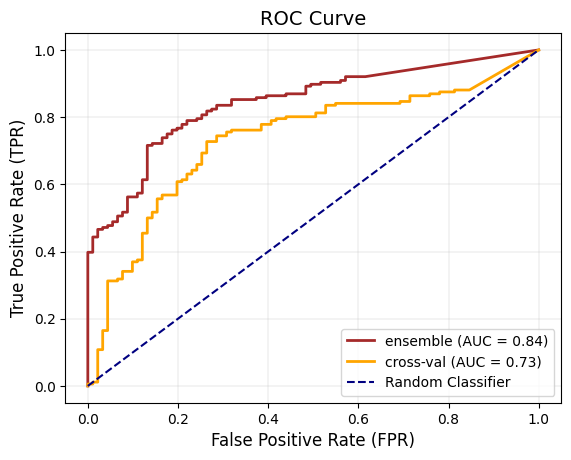

In [55]:
dmap.pl.roc_curve(df_res['DILI'], df_res['DILI_prob_ens'], label='ensemble', show=False)
dmap.pl.roc_curve(
    df_res['DILI'], df_res['DILI_prob_cv'], color='orange', label='cross-val', show=True
)

## 3c. Cross-validation of safety margins

In [56]:
idx = (~adata.obs['DILI'].isna()) & adata.obs['valid_cmpd']
adata.obs['DILI_prob_cv'] = np.nan

adata.obs.loc[idx, 'DILI_prob_cv'] = data.obs[
    'DILI_prob_cv'
]  # cross-validation results
adata.obs.loc[~idx, 'DILI_prob_cv'] = model.predict(adata[~idx].to_df())[
    'DILI_probability'
]  # use ensemble model to predict remaining compoumds

/var/folders/4g/179wj7wn0dn71d8dl8c91nb40000gp/T/ipykernel_46760/2746853614.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['DILI_prob_cv'] = np.nan
/opt/miniconda3/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/miniconda3/envs/py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [57]:
from dilimap.utils import crosstab

df_crosstab = crosstab(adata, ['compound_name', 'dose_level', 'DILI_prob_cv'])[
    ['Low', 'Middle', 'Mid-High', 'High']
]
display(
    df_crosstab.head(10)
    .style.format(precision=2)
    .background_gradient('RdBu_r', vmin=-0.2, vmax=1.25)
)

dose_level,Low,Middle,Mid-High,High
compound_name,,,,
Abacavir,0.00,0.10,0.79,0.94
Acarbose,0.13,0.69,0.91,0.90
Acebutolol,0.32,0.59,0.85,0.93
Aceclofenac,0.00,0.00,0.12,0.89
Acetaminophen,0.23,0.00,0.09,0.57
Alaproclate,0.56,0.67,0.80,0.92
Albendazole,0.61,0.77,0.82,0.87
Alfuzosin,0.00,0.00,0.11,0.90
Allopurinol,0.00,0.38,0.05,0.89


In [58]:
df_res_margins = model.compute_safety_margin(
    adata, 'compound_name', 'dose_uM', 'Cmax_uM', 'DILI_prob_cv', y_thresh=0.7
)
df_res_margins['DILI_label'] = df_res_margins.index.map(
    groupby(adata, 'compound_name')['DILI_label']
)
df_res_margins['n_DEG_mean'] = df_res_margins.index.map(
    groupby(adata, 'compound_name')['n_DEG_mean']
)

df_res_margins['DILI'] = ~df_res_margins['DILI_label'].str.startswith('No DILI')

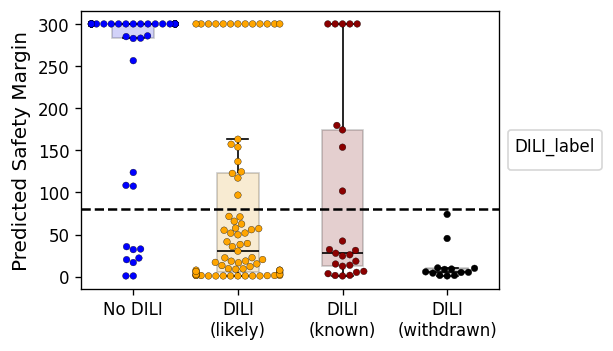

In [59]:
fig, ax = plt.subplots(figsize=(4.5, 3), dpi=120)
dmap.pl.boxplot_with_swarm(
    df_res_margins,
    box_width=0.4,
    swarm_size=4,
    x='DILI_label',
    y='MOS_ToxPredictor',
    hue_order=['No DILI', 'DILI (likely)', 'DILI (known)', 'DILI (withdrawn)'],
    palette=['blue', 'orange', 'darkred', 'k'],
    axhline=80,
    ylabel='Predicted Safety Margin',
    xlabel='',
)

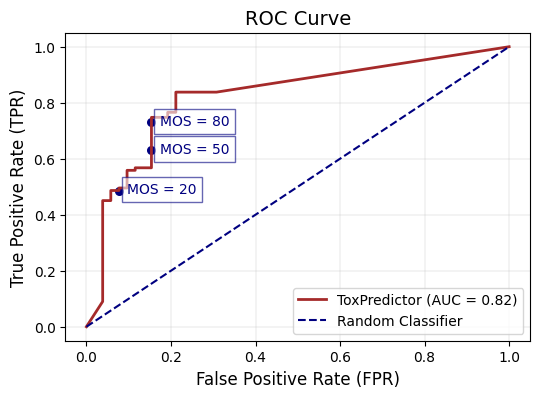

In [60]:
df_res_DILI = df_res_margins[
    df_res_margins['DILI_label'].isin(
        ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)', 'No DILI']
    )
]
y_true = ~df_res_DILI['DILI_label'].isin(['No DILI'])

plt.figure(figsize=(6, 4))
dmap.pl.roc_curve(
    y_true,
    df_res_DILI['MOS_ToxPredictor'],
    threshold_points=[20, 50, 80],
    threshold_name='MOS',
    label='ToxPredictor',
    inverse=True,
    show=True,
)

## Push model to quilt

In [61]:
# model.save_model('ToxPredictor_v1.joblib', push_to_s3=True)

In [62]:
# dmap.s3.write(data, 'ToxPredictor_v1_training_data.h5ad')